## **EDA Loan Risk Default**
## Credit Risk Prediction Across Two Financial Products

Object: Can we build and compare machine learning models to predict default risk across different credit products?

Original data set can be found here:
[Loan Default Prediction Dataset](https://www.kaggle.com/datasets/nikhil1e9/loan-default)

### 1. Packages and Loading data

In [1]:
# Importing packages
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Train-test split and model selection
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier)

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Classification metrics
from sklearn.metrics import (accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

# Load cleaning function
from data_0_cleaning import clean_datasets

In [2]:
# Load datasets
loan_df = pd.read_csv("Data/Loan_default.csv")
credit_df = pd.read_csv("Data/UCI_Credit_Card.csv")
# Clean datasets
loan_df, credit_df = clean_datasets(loan_df, credit_df)
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   customer_id     255347 non-null  object 
 1   age             255347 non-null  int64  
 2   income          255347 non-null  int64  
 3   loanamount      255347 non-null  int64  
 4   creditscore     255347 non-null  int64  
 5   monthsemployed  255347 non-null  int64  
 6   numcreditlines  255347 non-null  int64  
 7   interestrate    255347 non-null  float64
 8   loanterm        255347 non-null  int64  
 9   dtiratio        255347 non-null  float64
 10  education       255347 non-null  object 
 11  employmenttype  255347 non-null  object 
 12  maritalstatus   255347 non-null  object 
 13  hasmortgage     255347 non-null  object 
 14  hasdependents   255347 non-null  object 
 15  loanpurpose     255347 non-null  object 
 16  hascosigner     255347 non-null  object 
 17  default   

### 2. Checking main target variable "default" and features

In [3]:
print(loan_df["default"].value_counts(normalize=True) * 100) # the target variable is not balance

default
0    88.387175
1    11.612825
Name: proportion, dtype: float64


In [4]:
cat_cols = [
    "education",
    "employmenttype",
    "maritalstatus",
    "hasmortgage",
    "hasdependents",
    "loanpurpose",
    "hascosigner"]

for cat in cat_cols:
    print(loan_df[cat].value_counts())
    print("-" * 40)

education
Bachelor's     64366
High School    63903
Master's       63541
PhD            63537
Name: count, dtype: int64
----------------------------------------
employmenttype
Part-time        64161
Unemployed       63824
Self-employed    63706
Full-time        63656
Name: count, dtype: int64
----------------------------------------
maritalstatus
Married     85302
Divorced    85033
Single      85012
Name: count, dtype: int64
----------------------------------------
hasmortgage
Yes    127677
No     127670
Name: count, dtype: int64
----------------------------------------
hasdependents
Yes    127742
No     127605
Name: count, dtype: int64
----------------------------------------
loanpurpose
Business     51298
Home         51286
Education    51005
Other        50914
Auto         50844
Name: count, dtype: int64
----------------------------------------
hascosigner
Yes    127701
No     127646
Name: count, dtype: int64
----------------------------------------


There is no strange categories or incorrect values in the categorical varaibles. Data seems to be uniform!

In [5]:
def categorical_default_summary(df, column):
    summary = (
        df.groupby(column)
        .agg(
            clients=("default", "count"),
            defaults=("default", "sum"),
            default_rate=("default", "mean")
        )
        .reset_index()
    )
    
    summary["default_rate"] = summary["default_rate"] * 100
    summary["client_percentage"] = summary["clients"] / len(df) * 100
    
    return summary.sort_values(by="default_rate", ascending=False)

for col in cat_cols:
    print(f"\n{col}")
    display(categorical_default_summary(loan_df, col))


education


,education,clients,defaults,default_rate,client_percentage
1,High School,63903,8230,12.878895,25.025945
0,Bachelor's,64366,7789,12.101109,25.207267
2,Master's,63541,6908,10.871721,24.884177
3,PhD,63537,6726,10.585958,24.882611



employmenttype


,employmenttype,clients,defaults,default_rate,client_percentage
3,Unemployed,63824,8650,13.552895,24.995007
1,Part-time,64161,7677,11.965213,25.126984
2,Self-employed,63706,7302,11.462029,24.948795
0,Full-time,63656,6024,9.463366,24.929214



maritalstatus


,maritalstatus,clients,defaults,default_rate,client_percentage
0,Divorced,85033,10657,12.532781,33.300959
2,Single,85012,10127,11.912436,33.292735
1,Married,85302,8869,10.397177,33.406306



hasmortgage


,hasmortgage,clients,defaults,default_rate,client_percentage
0,No,127670,15761,12.345108,49.998629
1,Yes,127677,13892,10.880581,50.001371



hasdependents


,hasdependents,clients,defaults,default_rate,client_percentage
0,No,127605,16237,12.724423,49.973174
1,Yes,127742,13416,10.502419,50.026826



loanpurpose


,loanpurpose,clients,defaults,default_rate,client_percentage
1,Business,51298,6323,12.326017,20.089525
0,Auto,50844,6041,11.881441,19.911728
2,Education,51005,6038,11.838055,19.974779
4,Other,50914,6002,11.788506,19.939142
3,Home,51286,5249,10.234762,20.084826



hascosigner


,hascosigner,clients,defaults,default_rate,client_percentage
0,No,127646,16423,12.866051,49.98923
1,Yes,127701,13230,10.360138,50.01077


* Checking distributions for each numerical variable

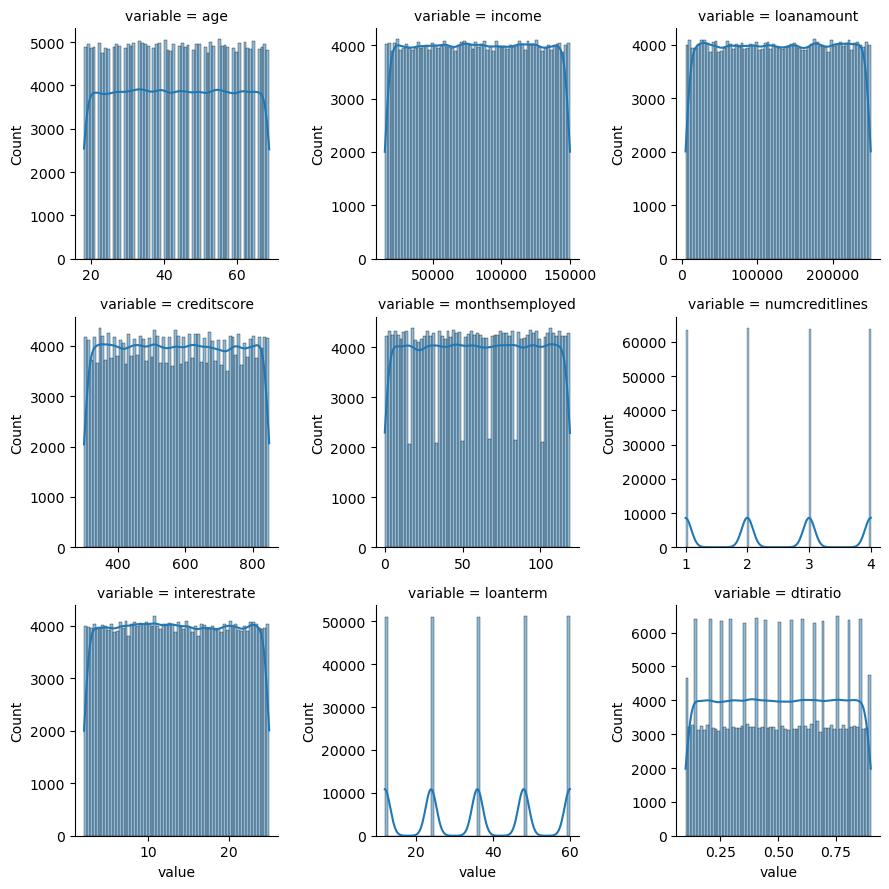

In [6]:
num_cols = [
    "age",
    "income",
    "loanamount",
    "creditscore",
    "monthsemployed",
    "numcreditlines",
    "interestrate",
    "loanterm",
    "dtiratio"]
df_melted = loan_df.melt(value_vars=num_cols)

g = sns.FacetGrid(
    df_melted, col="variable", col_wrap=3, sharex=False, sharey=False)
g.map(sns.histplot, "value", kde=True)
plt.tight_layout()
plt.show()


There are no extreme values, seems that the features are uniform. 

* Correlation heatmap

In [7]:
loan_corr = loan_df[num_cols + ["default"]].corr()
loan_corr["default"].sort_values(ascending=False)

default           1.000000
interestrate      0.131273
loanamount        0.086659
numcreditlines    0.028330
dtiratio          0.019236
loanterm          0.000545
creditscore      -0.034166
monthsemployed   -0.097374
income           -0.099119
age              -0.167783
Name: default, dtype: float64

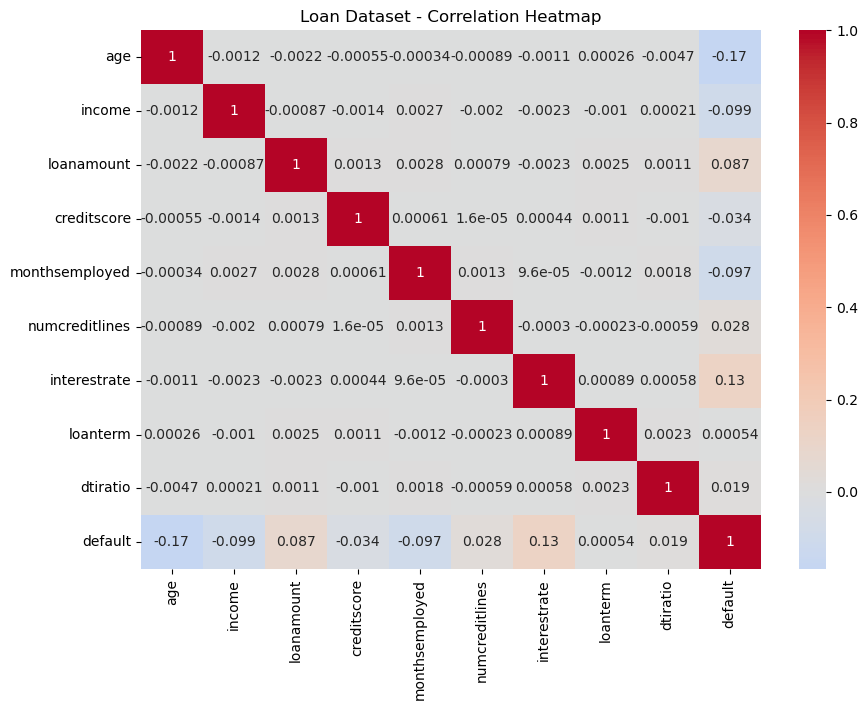

In [8]:
plt.figure(figsize=(10, 7))
sns.heatmap(loan_corr, cmap="coolwarm", center=0, annot=True)
plt.title("Loan Dataset - Correlation Heatmap")
plt.show()

The numerical correlation heatmap shows that most numerical features are weakly correlated with each other, suggesting no strong multicollinearity problem. Regarding the target variable, age, interest rate, income, months employed, and loan amount show the strongest relationships with default.

### 3. Feature engineering

In [9]:
# Loan burden: how large the loan is compared to income
loan_df["loan_to_income_ratio"] = loan_df["loanamount"] / (loan_df["income"] + 1)

# Employment stability in years
loan_df["years_employed"] = loan_df["monthsemployed"] / 12

# Interest burden: loan amount multiplied by interest rate
loan_df["interest_burden"] = loan_df["loanamount"] * (loan_df["interestrate"] / 100)

# Credit lines per income
loan_df["credit_lines_per_income"] = loan_df["numcreditlines"] / (loan_df["income"] + 1)

num_cols = [
    "age",
    "income",
    "loanamount",
    "creditscore",
    "monthsemployed",
    "numcreditlines",
    "interestrate",
    "loanterm",
    "dtiratio",
    "years_employed",
    "interest_burden",
    "credit_lines_per_income",
    "loan_to_income_ratio"]

cat_cols = [
    "education",
    "employmenttype",
    "maritalstatus",
    "hasmortgage",
    "hasdependents",
    "loanpurpose",
    "hascosigner"]



* Defining X and Y for the modeling

In [10]:
num_cols_x = loan_df.drop(columns=["customer_id", "default", "product_type"])
y = loan_df["default"]

In [11]:
# Encoding categorical variables/features
encoder = OneHotEncoder(
    drop="first",
    sparse_output=False,
    handle_unknown="ignore")

encoded_cat = encoder.fit_transform(num_cols_x[cat_cols])

encoded_cat_df = pd.DataFrame(
    encoded_cat,
    columns=encoder.get_feature_names_out(cat_cols),
    index=num_cols_x.index)

In [12]:
X_num = num_cols_x[num_cols]
X = pd.concat([X_num, encoded_cat_df], axis=1)
X.shape

(255347, 28)

In [13]:
loan_corr = pd.concat([X_num, encoded_cat_df, y], axis=1)
loan_corr_1 = loan_corr.corr()

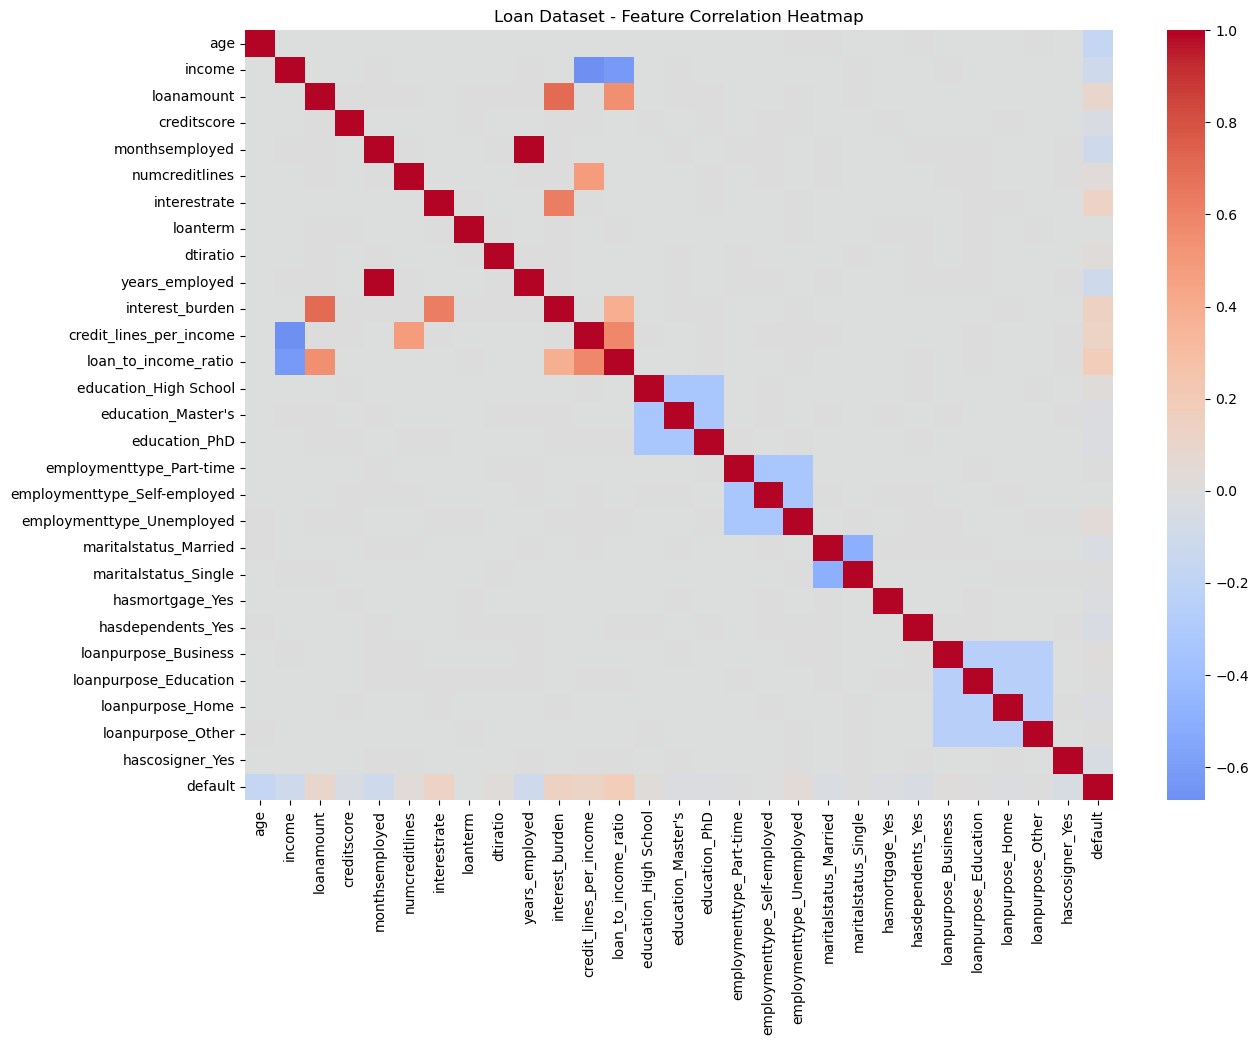

In [14]:
plt.figure(figsize=(14, 10))
sns.heatmap(loan_corr_1, cmap="coolwarm", center=0)
plt.title("Loan Dataset - Feature Correlation Heatmap")
plt.show()

In [15]:
X = X.drop(columns=["monthsemployed", "interestrate", "income"])
# To avoid multicolianity on the logistic regression, it is better to drop them

For the loan default dataset, several engineered features were created to capture financial burden and employment stability. Categorical variables were encoded using one-hot encoding with the first category dropped to avoid redundancy. After encoding, the dataset is split into training and testing sets, and the features are normalized before model training.

### **5. Models building**

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

* Normalizing process

In [17]:
normalizer = MinMaxScaler()
X_train_norm = normalizer.fit_transform(X_train)
X_test_norm = normalizer.transform(X_test)
X_train_norm = pd.DataFrame(X_train_norm, columns = X_train.columns)
X_test_norm = pd.DataFrame(X_test_norm, columns = X_test.columns)

#### 5.1. **First model: Logistic regression**

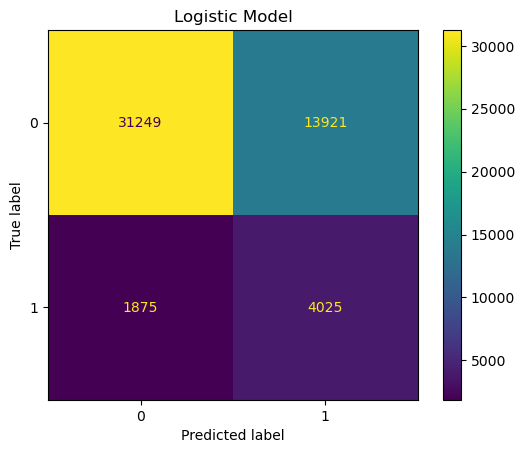

              precision    recall  f1-score   support

           0       0.94      0.69      0.80     45170
           1       0.22      0.68      0.34      5900

    accuracy                           0.69     51070
   macro avg       0.58      0.69      0.57     51070
weighted avg       0.86      0.69      0.75     51070



In [18]:
logistic_model = LogisticRegression(max_iter=1000, class_weight="balanced")
logistic_model.fit(X_train_norm, y_train)
logistic_pred = logistic_model.predict(X_test_norm)

cm = confusion_matrix(y_test, logistic_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Logistic Model")
plt.show()

print(classification_report(y_test, logistic_pred))

* SMOTE Sampling

In [19]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_norm,
    y_train)

print(pd.Series(y_train_smote).value_counts())

default
0    180524
1    180524
Name: count, dtype: int64


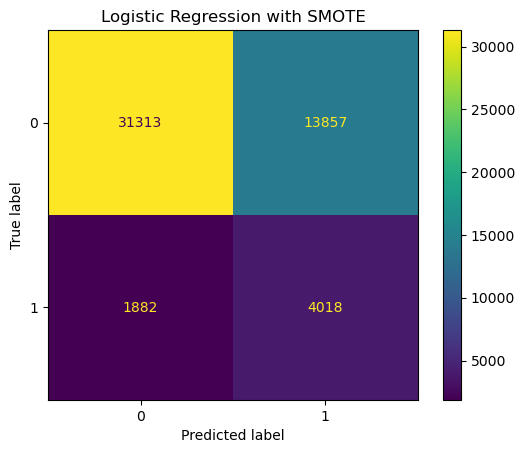

              precision    recall  f1-score   support

           0       0.94      0.69      0.80     45170
           1       0.22      0.68      0.34      5900

    accuracy                           0.69     51070
   macro avg       0.58      0.69      0.57     51070
weighted avg       0.86      0.69      0.75     51070



In [20]:
smote_logistic_model = LogisticRegression(max_iter=1000)
smote_logistic_model.fit(X_train_smote, y_train_smote)
smote_logistic_pred = smote_logistic_model.predict(X_test_norm)

cm = confusion_matrix(y_test, smote_logistic_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Logistic Regression with SMOTE")
plt.show()

print(classification_report(y_test, smote_logistic_pred))

Logistic Regression achieved high recall for the default class, detecting 68% of default cases. However, precision was low at 22%, meaning many non-default clients were incorrectly classified as risky. SMOTE did not improve performance substantially, suggesting that class imbalance handling alone is not enough for this dataset.

#### 5.2. **Second model: Random Forest Classifier**

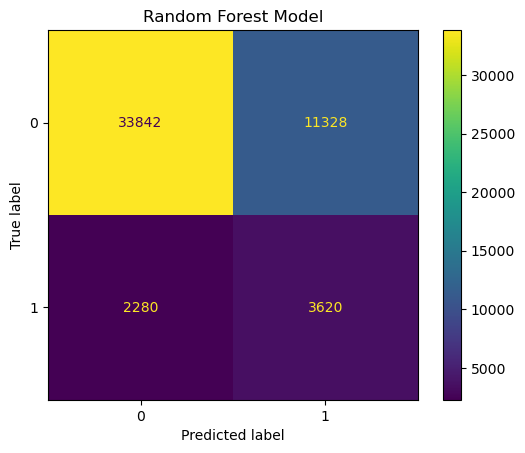

              precision    recall  f1-score   support

           0       0.94      0.75      0.83     45170
           1       0.24      0.61      0.35      5900

    accuracy                           0.73     51070
   macro avg       0.59      0.68      0.59     51070
weighted avg       0.86      0.73      0.78     51070



In [21]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1)

rf_model.fit(X_train_norm, y_train)

rf_pred = rf_model.predict(X_test_norm)

## Confusion Matriy
cm = confusion_matrix(y_test, rf_pred)

ConfusionMatrixDisplay(cm).plot()
plt.title("Random Forest Model")
plt.show()

print(classification_report(y_test, rf_pred))

#### 5.3. **Third model: Gradient Boosting Classifier**

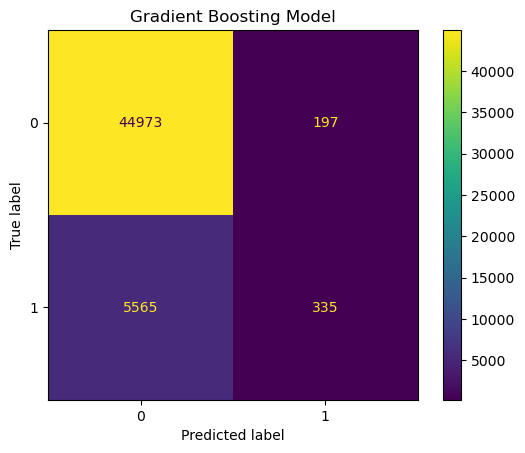

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45170
           1       0.63      0.06      0.10      5900

    accuracy                           0.89     51070
   macro avg       0.76      0.53      0.52     51070
weighted avg       0.86      0.89      0.84     51070



In [22]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42)

gb_model.fit(X_train_norm, y_train)

gb_pred = gb_model.predict(X_test_norm)

##
cm = confusion_matrix(y_test, gb_pred)

ConfusionMatrixDisplay(cm).plot()
plt.title("Gradient Boosting Model")
plt.show()

print(classification_report(y_test, gb_pred))

I have also tried subsmaple and adaboost, however those did not improve the model at all. 

In [23]:
results = pd.DataFrame({
    "model": [
        "Logistic Regression SMOTE",
        "Random Forest",
        "Gradient Boosting"
    ],
    "accuracy": [
        accuracy_score(y_test, smote_logistic_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],
    "precision": [
        precision_score(y_test, smote_logistic_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],
    "recall": [
        recall_score(y_test, smote_logistic_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],
    "f1_score": [
        f1_score(y_test, smote_logistic_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ],
    "roc_auc": [
        roc_auc_score(y_test, smote_logistic_model.predict_proba(X_test_norm)[:, 1]),
        roc_auc_score(y_test, rf_model.predict_proba(X_test_norm)[:, 1]),
        roc_auc_score(y_test, gb_model.predict_proba(X_test_norm)[:, 1])
    ]
})

results.sort_values(by="f1_score", ascending=False).T

,1,0,2
model,Random Forest,Logistic Regression SMOTE,Gradient Boosting
accuracy,0.733542,0.691815,0.887174
precision,0.242173,0.224783,0.629699
recall,0.613559,0.681017,0.05678
f1_score,0.347276,0.338002,0.104167
roc_auc,0.748073,0.754946,0.754977


Random Forest was selected as the final model for the loan default dataset because it achieved the highest F1-score for the default class. Although Logistic Regression with SMOTE achieved higher recall, its lower precision indicates many false positives. Gradient Boosting achieved high accuracy but very low recall, meaning it missed most default clients. Since the goal is to identify risky borrowers, Random Forest offers the most balanced performance.

* **Grid/Random Search** for Random Forest

In [24]:
rf_grid = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1)

# Defining hyperparameter grid
grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]}

random_search = RandomizedSearchCV(
    estimator=rf_grid,
    param_distributions=grid,
    n_iter=20,
    cv=5,
    scoring="f1",
    n_jobs=-1)

random_search.fit(X_train_norm, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,20
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [25]:
best_rf_model = random_search.best_estimator_
print("Best parameters:",random_search.best_params_)
print("Best CV score:", random_search.best_score_)

Best parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10}
Best CV score: 0.34271010669047874


In [26]:
train_score = best_rf_model.score(X_train_norm, y_train)
print("Training accuracy =", train_score)
test_score = best_rf_model.score(X_test_norm, y_test)
print("Test accuracy =", test_score)

Training accuracy = 0.7484592000078325
Test accuracy = 0.7329939299001371


ROC-AUC: 0.7469463345628381
--------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.75      0.83     45170
           1       0.24      0.61      0.35      5900

    accuracy                           0.73     51070
   macro avg       0.59      0.68      0.59     51070
weighted avg       0.86      0.73      0.78     51070



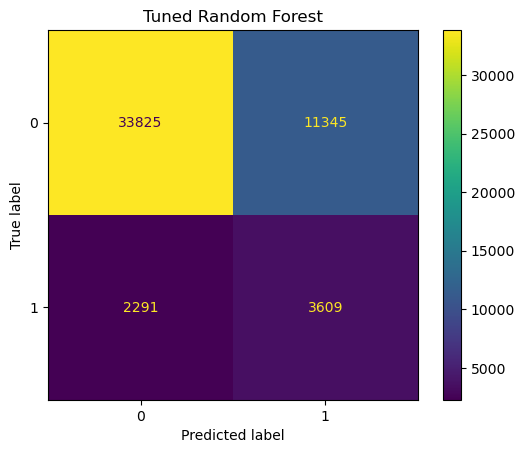

In [27]:
best_rf_pred = best_rf_model.predict(X_test_norm)
best_rf_proba = best_rf_model.predict_proba(X_test_norm)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, best_rf_proba))

print("--------------------------------------------")
print(classification_report(y_test, best_rf_pred))

cm = confusion_matrix(y_test, best_rf_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Tuned Random Forest")
plt.show()

In [28]:
tuned_results = pd.DataFrame({
    "model": ["Tuned Random Forest"],
    "accuracy": [accuracy_score(y_test, best_rf_pred)],
    "precision": [precision_score(y_test, best_rf_pred)],
    "recall": [recall_score(y_test, best_rf_pred)],
    "f1_score": [f1_score(y_test, best_rf_pred)],
    "roc_auc": [roc_auc_score(y_test, best_rf_proba)]
})

results_final = pd.concat([results, tuned_results], ignore_index=True)

results_final.sort_values(by="f1_score", ascending=False).T

,1,3,0,2
model,Random Forest,Tuned Random Forest,Logistic Regression SMOTE,Gradient Boosting
accuracy,0.733542,0.732994,0.691815,0.887174
precision,0.242173,0.24134,0.224783,0.629699
recall,0.613559,0.611695,0.681017,0.05678
f1_score,0.347276,0.346121,0.338002,0.104167
roc_auc,0.748073,0.746946,0.754946,0.754977


In [29]:
results_final.sort_values(by="f1_score", ascending=False).T.to_csv("Results\Model_comparison_results_loan.csv", index=True) # saving

The Random Forest model was selected as the final model for the loan default dataset. Although hyperparameter tuning was applied using RandomizedSearchCV, the tuned model did not improve the original Random Forest performance. 

### **Final: Storing data set for the dashboard**

In [30]:
df2 = loan_df.loc[X_test.index].copy()

df2["default_probability"] = rf_model.predict_proba(X_test_norm)[:, 1]
df2["predicted_default"] = rf_model.predict(X_test_norm)
df2["actual_default"] = y_test.values

def risk_segment(prob):
    if prob >= 0.70:
        return "High Risk"
    elif prob >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

df2["risk_segment"] = df2["default_probability"].apply(risk_segment)

df2.head()

,customer_id,age,income,loanamount,creditscore,monthsemployed,numcreditlines,interestrate,loanterm,dtiratio,...,default,product_type,loan_to_income_ratio,years_employed,interest_burden,credit_lines_per_income,default_probability,predicted_default,actual_default,risk_segment
51139,CKV34LU7V7,55,112656,92393,581,113,2,23.54,36,0.15,...,0,Loan,0.820127,9.416667,21749.3122,0.000018,0.263131,0,0,Low Risk
71005,62KTYNH93J,56,91569,131575,641,54,1,15.19,12,0.43,...,0,Loan,1.436879,4.500000,19986.2425,0.000011,0.294472,0,0,Low Risk
35684,JGFUSOIUH7,26,78169,75417,569,105,3,18.02,12,0.29,...,0,Loan,0.964782,8.750000,13590.1434,0.000038,0.412226,0,0,Medium Risk
174087,4538THBHOX,26,63033,10804,326,118,1,14.71,24,0.41,...,0,Loan,0.171400,9.833333,1589.2684,0.000016,0.369285,0,0,Low Risk
137952,DXLNA06JHR,24,29665,21182,662,102,3,15.02,60,0.69,...,0,Loan,0.714016,8.500000,3181.5364,0.000101,0.416428,0,0,Medium Risk


In [31]:
df2["actual_default_label"] = df2["actual_default"].map({
    0: "No Default",
    1: "Default"})

df2["predicted_default_label"] = df2["predicted_default"].map({
    0: "Predicted No Default",
    1: "Predicted Default"})

df2.head()

,customer_id,age,income,loanamount,creditscore,monthsemployed,numcreditlines,interestrate,loanterm,dtiratio,...,loan_to_income_ratio,years_employed,interest_burden,credit_lines_per_income,default_probability,predicted_default,actual_default,risk_segment,actual_default_label,predicted_default_label
51139,CKV34LU7V7,55,112656,92393,581,113,2,23.54,36,0.15,...,0.820127,9.416667,21749.3122,0.000018,0.263131,0,0,Low Risk,No Default,Predicted No Default
71005,62KTYNH93J,56,91569,131575,641,54,1,15.19,12,0.43,...,1.436879,4.500000,19986.2425,0.000011,0.294472,0,0,Low Risk,No Default,Predicted No Default
35684,JGFUSOIUH7,26,78169,75417,569,105,3,18.02,12,0.29,...,0.964782,8.750000,13590.1434,0.000038,0.412226,0,0,Medium Risk,No Default,Predicted No Default
174087,4538THBHOX,26,63033,10804,326,118,1,14.71,24,0.41,...,0.171400,9.833333,1589.2684,0.000016,0.369285,0,0,Low Risk,No Default,Predicted No Default
137952,DXLNA06JHR,24,29665,21182,662,102,3,15.02,60,0.69,...,0.714016,8.500000,3181.5364,0.000101,0.416428,0,0,Medium Risk,No Default,Predicted No Default


In [32]:
df2.to_csv("Results/loan_dashboard_predictions.csv", index=False)

* Feature Importance

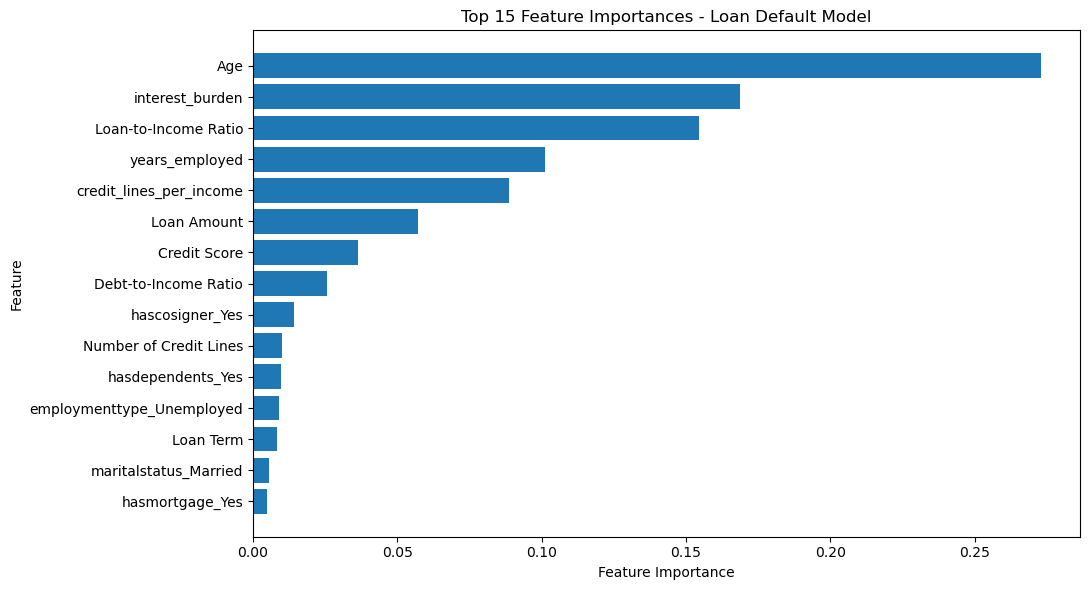

In [ ]:
best_rf_model = random_search.best_estimator_

feature_names = X_train.columns
importances = best_rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances})

# Cleaner labels for presentation
feature_labels = {
    "age": "Age",
    "income": "Income",
    "loanamount": "Loan Amount",
    "creditscore": "Credit Score",
    "monthsemployed": "Months Employed",
    "numcreditlines": "Number of Credit Lines",
    "interestrate": "Interest Rate",
    "loanterm": "Loan Term",
    "dtiratio": "Debt-to-Income Ratio",
    "loan_to_income_ratio": "Loan-to-Income Ratio",
    "education": "Education",
    "employmenttype": "Employment Type",
    "maritalstatus": "Marital Status",
    "hasmortgage": "Has Mortgage",
    "hasdependents": "Has Dependents",
    "loanpurpose": "Loan Purpose",
    "hascosigner": "Has Cosigner"}

# Apply clean labels
feature_importance_df["feature_label"] = feature_importance_df["feature"].replace(feature_labels)

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False)

# Select top 15
top_features = feature_importance_df.head(15)

# Plot
plt.figure(figsize=(11, 6))

plt.barh(
    top_features["feature_label"][::-1],
    top_features["importance"][::-1])

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Loan Default Model")

plt.tight_layout()
plt.show()